In [1]:
from aeon.benchmarking.published_results import load_classification_bake_off_2023_results
from aeon.visualisation import plot_critical_difference
import polars as pl
import numpy as np
from aeon.datasets.tsc_datasets import univariate
from tscglue import utils
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
directory = "figures"
Path(directory).mkdir(parents=True, exist_ok=True)

TSCGLUE_MODEL = "TSCGlue-17-4-26"

In [3]:
from tscglue.utils import load_s3_parquet_cached

results_arr, datasets, classifiers = load_classification_bake_off_2023_results(
    num_resamples=30, as_array=True
)

res_mine = load_s3_parquet_cached(skip_empty=True)
df_bakeoff = pl.DataFrame(results_arr, schema=classifiers).with_columns(pl.Series("dataset", datasets))
df_mine = res_mine.filter(pl.col("model") == TSCGLUE_MODEL).pivot(
    values="test_accuracy", index="dataset", on="model", aggregate_function="mean"
)
df_full = df_bakeoff.join(df_mine, on="dataset").drop_nulls()

100%|██████████| 1/1 [00:00<00:00,  2.84it/s]


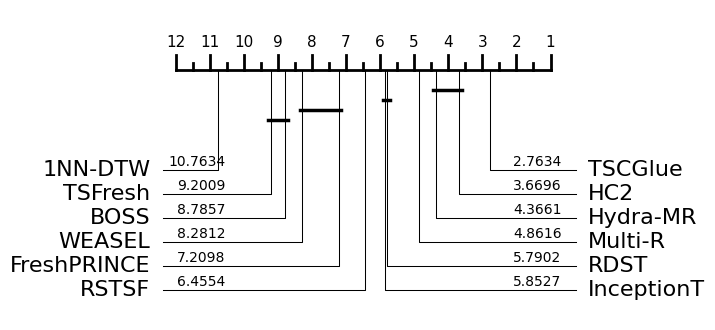

In [4]:
drop_models = {"cBOSS", "WEASEL-D", "ROCKET", "TS-CHIEF", "RSF", "MrSQM", "STC", "HC1", "ResNet", "ShapeDTW", "PF", "Mini-R", "DrCIF", "EE", "Catch22", "CNN", "CIF", "Hydra", "RISE", "TDE", "TSF", "Signatures", "Arsenal"}

clsf = df_full.select([
    c for c in df_full.columns
    if c != "dataset" and c not in drop_models and (c in classifiers or c == TSCGLUE_MODEL)
]).rename({TSCGLUE_MODEL: "TSCGlue"})
plot_critical_difference(clsf.to_numpy(), clsf.columns)
plt.savefig(f"{directory}/critical_difference.pdf", bbox_inches="tight", pad_inches=0)

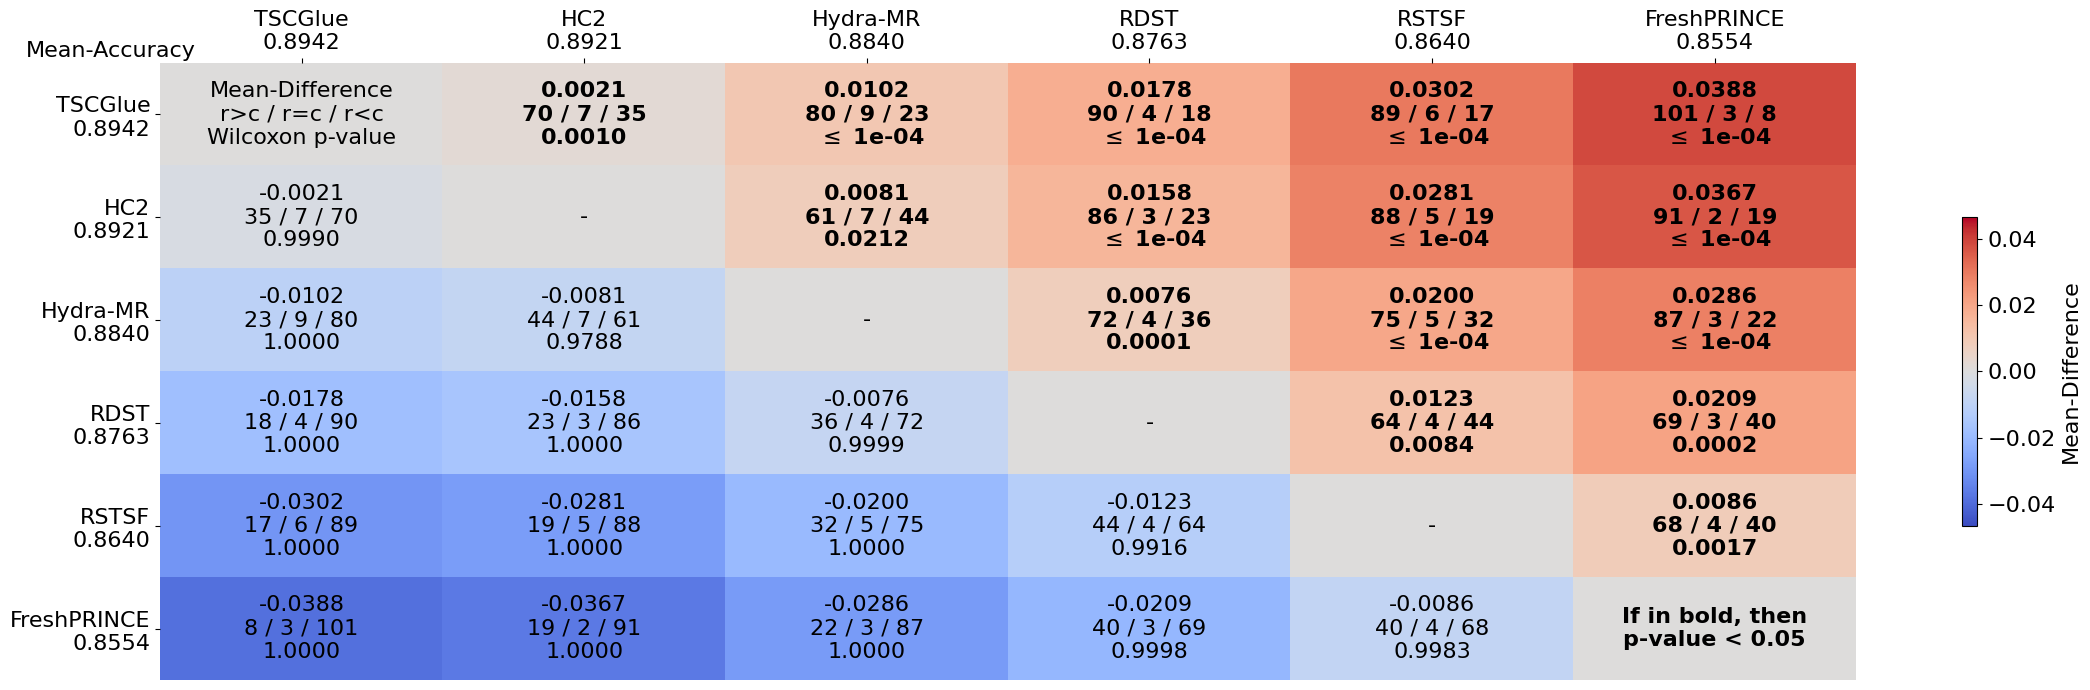

In [5]:
drop_models = {"1NN-DTW","InceptionT","cBOSS", "Multi-R", "WEASEL", "WEASEL-D", "ROCKET", "TS-CHIEF", "RSF", "MrSQM", "STC", "HC1", "ResNet", "ShapeDTW", "TSFresh", "PF", "Mini-R", "DrCIF", "EE", "Catch22", "CNN", "CIF", "BOSS", "Hydra", "RISE", "TDE", "TSF", "Signatures", "Arsenal"}
clsf = df_full.select([
    c for c in df_full.columns
    if c != "dataset" and c not in drop_models and (c in classifiers or c == TSCGLUE_MODEL)
]).rename({TSCGLUE_MODEL: "TSCGlue"})

from aeon.visualisation import create_multi_comparison_matrix

create_multi_comparison_matrix(clsf.to_pandas(), font_size=16)
plt.savefig(f"{directory}/multi_comparison_matrix.pdf", bbox_inches="tight", pad_inches=0)

In [6]:
stats = pl.DataFrame([
    {"dataset": d, "n_train": utils.load_dataset(d)[0].shape[0]}
    for d in df_full["dataset"].to_list()
])

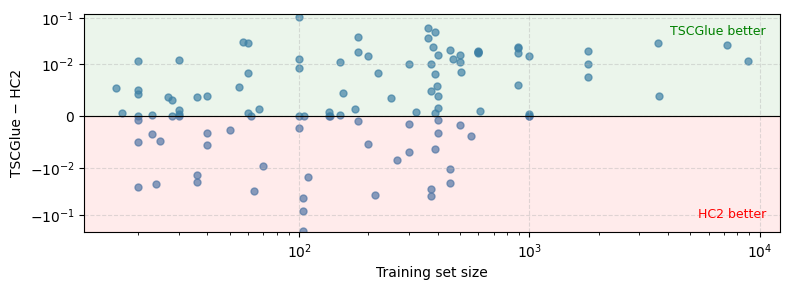

In [7]:
data = (
    df_full.join(stats, on="dataset")
    .with_columns((pl.col(TSCGLUE_MODEL) - pl.col("HC2")).alias("diff"))
    .sort("n_train")
)

fig, ax = plt.subplots(figsize=(8, 3))
ax.scatter(data["n_train"], data["diff"], s=25, alpha=0.7, color="steelblue")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlabel("Training set size")
ax.set_ylabel("TSCGlue − HC2")
ax.set_xscale("log")
ax.grid(True, linestyle="--", alpha=0.4)
ylim = ax.get_ylim()
ax.axhspan(0, ylim[1], alpha=0.08, color="green")
ax.axhspan(ylim[0], 0, alpha=0.08, color="red")
ax.text(0.98, 0.95, "TSCGlue better", transform=ax.transAxes, ha="right", va="top", fontsize=9, color="green")
ax.text(0.98, 0.05, "HC2 better",     transform=ax.transAxes, ha="right", va="bottom", fontsize=9, color="red")
ax.set_ylim(ylim)
ax.set_yscale("symlog", linthresh=0.01)
plt.tight_layout()
plt.savefig(f"{directory}/hcv2_vs_tscglue.pdf", bbox_inches="tight", pad_inches=0)

In [ ]:
from tscglue.utils import S3FileCache

timing_cache = S3FileCache("s3://anonymous-bucket/lokystacker-timing")
df_timing = timing_cache.read_all_parquet_cached()

In [9]:
label_datasets = [
    "ACSF1",
    #"Adiac",
    "AllGestureWiimoteX",
    "AllGestureWiimoteY",
    "AllGestureWiimoteZ",
    "ArrowHead",
    "BME",
    #"Beef",
    "BeetleFly",
    "BirdChicken",
    "CBF",
    "Car",
    "Chinatown",
    "ChlorineConcentration",
    "CinCECGTorso",
    "Coffee",
    "Computers",
    "CricketX",
    #"CricketY",
    #"CricketZ",
    "Crop",
    "DiatomSizeReduction",
    #"DistalPhalanxOutlineAgeGroup",
    #"DistalPhalanxOutlineCorrect",
    "DistalPhalanxTW",
    "DodgerLoopDay",
    #"DodgerLoopGame",
    #"DodgerLoopWeekend",
    #"ECG200",
    "ECG5000",
    "ECGFiveDays",
    "EOGHorizontalSignal",
    "EOGVerticalSignal",
    "Earthquakes",
    "ElectricDevices",
    "EthanolLevel",
    #"FaceAll",
    "FaceFour",
    #"FacesUCR",
    #"FiftyWords",
    "Fish",
    "FordA",
    "FordB",
    "FreezerRegularTrain",
    "FreezerSmallTrain",
    "Fungi",
    "GestureMidAirD1",
    #"GestureMidAirD2",
    #"GestureMidAirD3",
    "GesturePebbleZ1",
    #"GesturePebbleZ2",
    "GunPoint",
    #"GunPointAgeSpan",
    #"GunPointMaleVersusFemale",
    #"GunPointOldVersusYoung",
    "Ham",
    "HandOutlines",
    "Haptics",
    #"Herring",
    "HouseTwenty",
    "InlineSkate",
    "InsectEPGRegularTrain",
    #"InsectEPGSmallTrain",
    #"InsectWingbeatSound",
    "ItalyPowerDemand",
    "LargeKitchenAppliances",
    "Lightning2",
    #"Lightning7",
    "Mallat",
    "Meat",
    "MedicalImages",
    "MelbournePedestrian",
    "MiddlePhalanxOutlineAgeGroup",
    #"MiddlePhalanxOutlineCorrect",
    #"MiddlePhalanxTW",
    "MixedShapesRegularTrain",
    #"MixedShapesSmallTrain",
    "MoteStrain",
    "NonInvasiveFetalECGThorax1",
    #"NonInvasiveFetalECGThorax2",
    #"OSULeaf",
    "OliveOil",
    #"PLAID",
    "PhalangesOutlinesCorrect",
    "Phoneme",
    "PickupGestureWiimoteZ",
    "PigAirwayPressure",
    "PigArtPressure",
    "PigCVP",
    "Plane",
    "PowerCons",
    "ProximalPhalanxOutlineAgeGroup",
    #"ProximalPhalanxOutlineCorrect",
    #"ProximalPhalanxTW",
    "RefrigerationDevices",
    "Rock",
    "ScreenType",
    #"SemgHandGenderCh2",
    #"SemgHandMovementCh2",
    #"SemgHandSubjectCh2",
    "ShakeGestureWiimoteZ",
    "ShapeletSim",
    "ShapesAll",
    "SmallKitchenAppliances",
    "SmoothSubspace",
    "SonyAIBORobotSurface1",
    #"SonyAIBORobotSurface2",
    "StarLightCurves",
    #"Strawberry",
    #"SwedishLeaf",
    "Symbols",
    "SyntheticControl",
    "ToeSegmentation1",
    #"ToeSegmentation2",
    "Trace",
    "TwoLeadECG",
    "TwoPatterns",
    "UMD",
    #"UWaveGestureLibraryAll",
    #"UWaveGestureLibraryX",
    #"UWaveGestureLibraryY",
    "UWaveGestureLibraryZ",
    "Wafer",
    "Wine",
    #"WordSynonyms",
    #"Worms",
    "WormsTwoClass",
    "Yoga",
]

#label_datasets = []

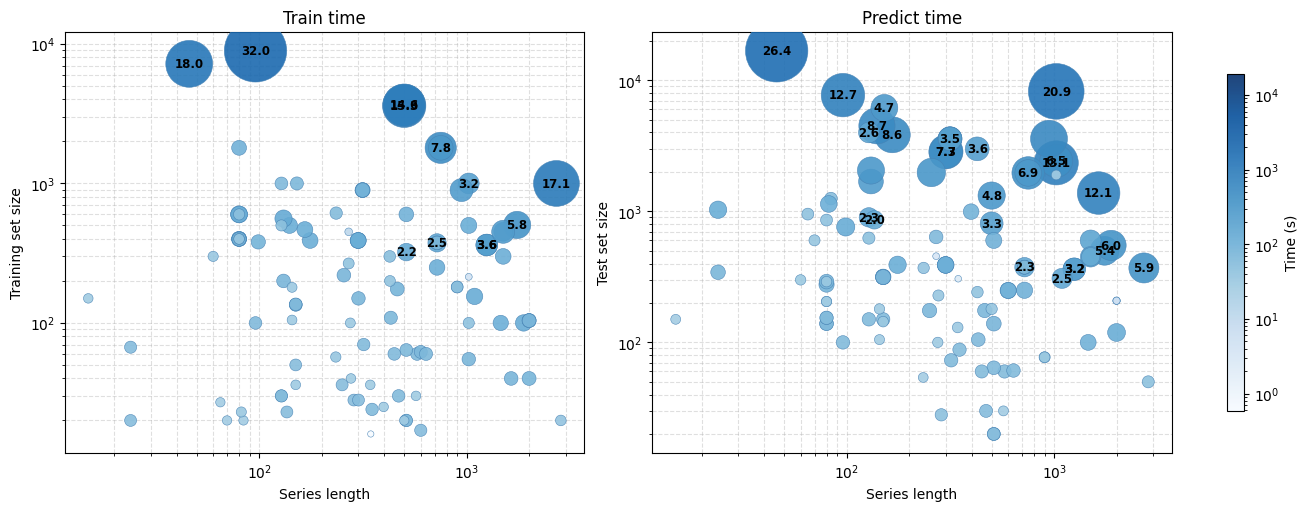

In [10]:
t_all = np.concatenate([df_timing["train_time_s"].to_numpy(), df_timing["predict_time_s"].to_numpy()])
shared_norm = plt.matplotlib.colors.LogNorm(vmin=t_all.min(), vmax=t_all.max() * 10)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)

for ax, time_col, title, ylabel in [
    (axes[0], "train_time_s",   "Train time",   "Training set size"),
    (axes[1], "predict_time_s", "Predict time", "Test set size"),
]:
    n = df_timing["n_train"] if time_col == "train_time_s" else df_timing["n_test"]
    t = df_timing[time_col].to_numpy()
    sizes = (t / t.max()) * 2000 + 20

    sc = ax.scatter(
        df_timing["series_len"], n, s=sizes,
        c=t, cmap="Blues", norm=shared_norm,
        alpha=0.9, edgecolors="steelblue", linewidths=0.4, zorder=3,
    )
    for xi, yi, lbl, ti in zip(df_timing["series_len"], n, df_timing["dataset"], t):
        if lbl not in label_datasets:
            continue
        #ax.annotate(lbl, (xi, yi), textcoords="offset points", xytext=(5, 4), fontsize=7.5)
        if ti > 120:
            ax.annotate(
                f"{ti/60:.1f}", (xi, yi),
                ha="center", va="center", fontsize=8.5, fontweight="bold", color="black", zorder=4,
            )
    ax.set_xlabel("Series length")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.grid(True, which="both", linestyle="--", alpha=0.4)

fig.colorbar(sc, ax=axes, label="Time (s)", shrink=0.8)
plt.savefig(f"{directory}/train-inference-time.pdf", bbox_inches="tight", pad_inches=0)


In [ ]:
from tscglue.utils import S3FileCache

timing_cache_all = S3FileCache("s3://anonymous-bucket/performance-timing-slurm/timing_runs_slurm")
df_timing_all = timing_cache_all.read_all_parquet_cached()

timing_models = ["multirockethydra", "hcv2", "TSCGlue-17-4-26"]

df_timing_agg = (
    df_timing_all
    .filter(
        pl.col("model").is_in(timing_models)
        & pl.col("n_jobs").is_in([1, 16])
    )
    .group_by(["model", "n_jobs"])
    .agg([
        pl.len().alias("n_runs"),
        (pl.col("fit_time_s").sum() / 60).alias("total_train_min"),
        (pl.col("predict_time_s").sum() / 60).alias("total_inference_min"),
        (pl.col("total_time_s").sum() / 60).alias("total_runtime_min"),
        (pl.col("total_time_s").mean() / 60).alias("mean_total_per_dataset_min"),
        (1 / (pl.col("fit_time_s") / pl.col("n_train")).mean()).alias("train_inst_per_s"),
        (1 / (pl.col("predict_time_s") / pl.col("n_test")).mean()).alias("test_inst_per_s"),
    ])
    .sort(["model", "n_jobs"])
)


# Ablation Study — Component Contribution

Compare each single-component model against the full `LokyStackerV10RSTSFRandom` ensemble.

In [13]:
FULL_MODEL = "loky-stacker-v10-rstsf-random"
ABLATION_MODELS = [
    "ablation-multirockethydra-bestk-p-ridgecv",
    "ablation-quant-etc",
    "ablation-rdst-p-ridgecv",
    "ablation-rstsf-random-etc",
    "ablation-fm-p-ridgecv",
]
ALL_MODELS = ABLATION_MODELS + [FULL_MODEL]

SHORT_NAMES = {
    "ablation-multirockethydra-bestk-p-ridgecv": "MultiRocketHydra",
    "ablation-quant-etc":                        "Quant",
    "ablation-rdst-p-ridgecv":                   "RDST",
    "ablation-rstsf-random-etc":                 "RSTSF",
    "ablation-fm-p-ridgecv":                     "TSFM",
    FULL_MODEL:                                  "TSCGlue",
}

In [14]:
df = res_mine.filter(pl.col("model").is_in(ALL_MODELS))
print(f"Loaded {len(df)} rows across {df['dataset'].n_unique()} datasets")
df.group_by("model").agg(
    pl.len().alias("n_rows"),
    pl.col("dataset").n_unique().alias("n_datasets"),
).sort("model")

Loaded 20160 rows across 112 datasets


model,n_rows,n_datasets
str,u32,u32
"""ablation-fm-p-ridgecv""",3360,112
"""ablation-multirockethydra-best…",3360,112
"""ablation-quant-etc""",3360,112
"""ablation-rdst-p-ridgecv""",3360,112
"""ablation-rstsf-random-etc""",3360,112
"""loky-stacker-v10-rstsf-random""",3360,112


112


/tmp/ipykernel_2213167/1577079051.py:16: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig("figures/ablation_cd.pdf", bbox_inches="tight", pad_inches=0)
/tmp/ipykernel_2213167/1577079051.py:16: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig("figures/ablation_cd.pdf", bbox_inches="tight", pad_inches=0)
/home/petelin/TSCGlue/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


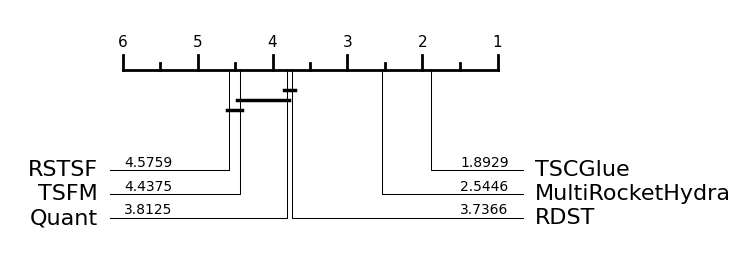

In [15]:
# Pivot: mean accuracy per dataset per model (averaged over folds)
perf = (
    df.group_by(["dataset", "model"])
    .agg(pl.col("test_accuracy").mean())
    .pivot(values="test_accuracy", index="dataset", on="model", aggregate_function="mean")
    .drop_nulls()
)

print(len(perf))

# Rename to short names for the plot
perf_renamed = perf.rename({m: SHORT_NAMES[m] for m in ALL_MODELS if m in perf.columns})
clsf = perf_renamed.select([SHORT_NAMES[m] for m in ALL_MODELS if SHORT_NAMES[m] in perf_renamed.columns])

plot_critical_difference(clsf.to_numpy(), clsf.columns)
plt.savefig("figures/ablation_cd.pdf", bbox_inches="tight", pad_inches=0)

In [16]:
plotted_models = [m for m in ALL_MODELS if m in perf.columns]
df.filter(pl.col("model").is_in(plotted_models)).group_by(["dataset", "model"]).agg(pl.len().alias("n_folds")).group_by("model").agg(
    pl.col("n_folds").sum().alias("n_rows"),
    pl.col("dataset").n_unique().alias("n_datasets"),
    pl.col("n_folds").mean().alias("avg_folds_per_dataset"),
).sort("model")


model,n_rows,n_datasets,avg_folds_per_dataset
str,u32,u32,f64
"""ablation-fm-p-ridgecv""",3360,112,30.0
"""ablation-multirockethydra-best…",3360,112,30.0
"""ablation-quant-etc""",3360,112,30.0
"""ablation-rdst-p-ridgecv""",3360,112,30.0
"""ablation-rstsf-random-etc""",3360,112,30.0
"""loky-stacker-v10-rstsf-random""",3360,112,30.0


# Stacking Variants

112


/tmp/ipykernel_2213167/2606007576.py:28: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig(f"{directory}/stacking_best.pdf", bbox_inches="tight", pad_inches=0)
/tmp/ipykernel_2213167/2606007576.py:28: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig(f"{directory}/stacking_best.pdf", bbox_inches="tight", pad_inches=0)
/home/petelin/TSCGlue/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


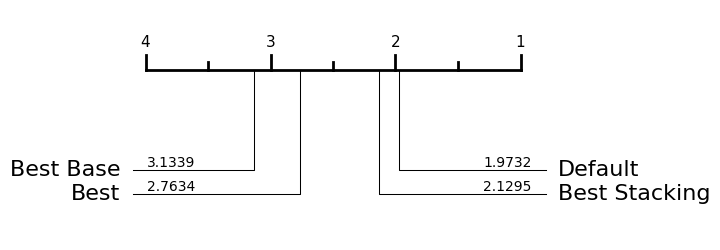

In [17]:
v10_models = [
    "multistack-ridgecv",
    "multistack-best",
    "multistack-best-base",
    "multistack-best-stacking",
]

v10_names = {
    "multistack-ridgecv":       "Default",
    "multistack-best":          "Best",
    "multistack-best-base":     "Best Base",
    "multistack-best-stacking": "Best Stacking",
}

clsf_v10 = (
    res_mine.filter(pl.col("model").is_in(v10_models))
    .group_by(["dataset", "model"])
    .agg(pl.col("test_accuracy").mean())
    .pivot(values="test_accuracy", index="dataset", on="model", aggregate_function="mean")
    .drop_nulls()
    .select(v10_models)
    .rename(v10_names)
)

print(len(clsf_v10))

plot_critical_difference(clsf_v10.to_numpy(), clsf_v10.columns)
plt.savefig(f"{directory}/stacking_best.pdf", bbox_inches="tight", pad_inches=0)

In [18]:
res_mine.filter(pl.col("model").is_in(v10_models)).group_by("model").agg(
    pl.len().alias("n_rows"),
    pl.col("dataset").n_unique().alias("n_datasets"),
).sort("model")

model,n_rows,n_datasets
str,u32,u32
"""multistack-best""",3313,112
"""multistack-best-base""",3317,112
"""multistack-best-stacking""",3356,112
"""multistack-ridgecv""",3318,112


# Components Comparison — TSCGlue-17-4-26

105


/tmp/ipykernel_2213167/1833240890.py:26: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig(f"{directory}/components_tscglue.pdf", bbox_inches="tight", pad_inches=0)
/tmp/ipykernel_2213167/1833240890.py:26: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig(f"{directory}/components_tscglue.pdf", bbox_inches="tight", pad_inches=0)
/home/petelin/TSCGlue/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


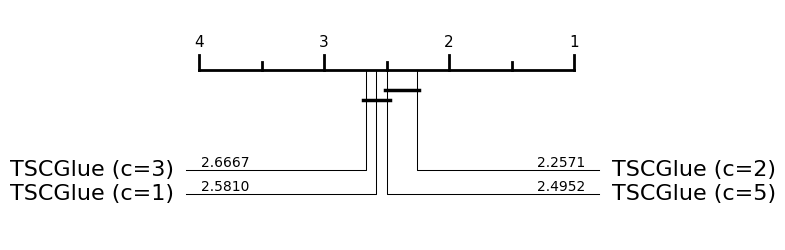

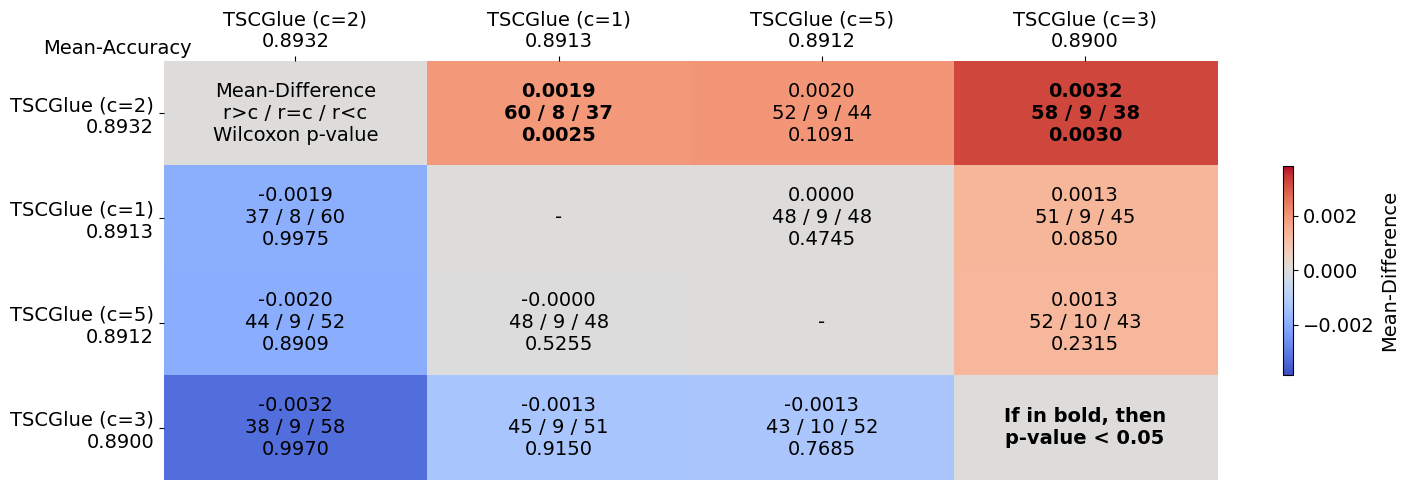

In [23]:
c_tscglue_models = [
    "TSCGlue-17-4-26",
    "TSCGlue-17-4-26-c2",
    "TSCGlue-17-4-26-c3",
    "TSCGlue-17-4-26-c5",
]

c_tscglue_names = {
    "TSCGlue-17-4-26":    "TSCGlue (c=1)",
    "TSCGlue-17-4-26-c2": "TSCGlue (c=2)",
    "TSCGlue-17-4-26-c3": "TSCGlue (c=3)",
    "TSCGlue-17-4-26-c5": "TSCGlue (c=5)",
}

clsf_c_tscglue = (
    res_mine.filter(pl.col("model").is_in(c_tscglue_models))
    .group_by(["dataset", "model"])
    .agg(pl.col("test_accuracy").mean())
    .pivot(values="test_accuracy", index="dataset", on="model", aggregate_function="mean")
    .drop_nulls()
    .select(c_tscglue_models)
    .rename(c_tscglue_names)
)
print(len(clsf_c_tscglue))
plot_critical_difference(clsf_c_tscglue.to_numpy(), clsf_c_tscglue.columns)
plt.savefig(f"{directory}/components_tscglue.pdf", bbox_inches="tight", pad_inches=0)

create_multi_comparison_matrix(clsf_c_tscglue.to_pandas(), font_size=14)
plt.savefig(f"{directory}/components_tscglue_mcm.pdf", bbox_inches="tight", pad_inches=0)

In [24]:
res_mine.filter(pl.col("model").is_in(c_tscglue_models)).group_by("model").agg(
    pl.len().alias("n_rows"),
    pl.col("dataset").n_unique().alias("n_datasets"),
).sort("model")

model,n_rows,n_datasets
str,u32,u32
"""TSCGlue-17-4-26""",3356,112
"""TSCGlue-17-4-26-c2""",1064,106
"""TSCGlue-17-4-26-c3""",1003,107
"""TSCGlue-17-4-26-c5""",482,105
